Reorder dataset

In [1]:
# import os
# import shutil
# from tqdm import tqdm

# def reorder_folders(src_root, dst_root):
    
#     for fol in tqdm(os.listdir(src_root)):
        
#         fol_path = os.path.join(src_root, fol)
#         if not os.path.isdir(fol_path):
#             continue

#         dst_fol = os.path.join(dst_root, fol)
#         os.makedirs(dst_fol, exist_ok=True)

#         parts = ["bottom", "center", "left", "right", "top"]
#         for p in parts:
#             os.makedirs(os.path.join(dst_fol, p), exist_ok=True)

#         for i in range(49):
#             i_path = os.path.join(fol_path, str(i))
#             if not os.path.isdir(i_path):
#                 continue

#             file_rgb = {
#                             "bottom": "result_scaled_image_bottom.jpg",
#                             "center": "result_scaled_image_center.jpg",
#                             "left": "result_scaled_image_left.jpg",
#                             "right": "result_scaled_image_right.jpg",
#                             "top": "result_scaled_image_top.jpg",
#                         }

#             file_up_left = {
#                             "bottom": "result_up_pd_left_bottom.png",
#                             "center": "result_up_pd_left_center.png",
#                             "left": "result_up_pd_left_left.png",
#                             "right": "result_up_pd_left_right.png",
#                             "top": "result_up_pd_left_top.png",
#                         }

#             file_up_right = {
#                             "bottom": "result_up_pd_right_bottom.png",
#                             "center": "result_up_pd_right_center.png",
#                             "left": "result_up_pd_right_left.png",
#                             "right": "result_up_pd_right_right.png",
#                             "top": "result_up_pd_right_top.png",
#                         }

#             file_camera = {
#                             "bottom": "result_scaled_camera_post_bottom.txt",
#                             "center": "result_scaled_camera_post_center.txt",
#                             "left": "result_scaled_camera_post_left.txt",
#                             "right": "result_scaled_camera_post_right.txt",
#                             "top": "result_scaled_camera_post_top.txt",
#                         }
            
#             files = file_camera

#             for k, fname in files.items():
#                 src_file = os.path.join(i_path, fname)
                
#                 if os.path.exists(src_file):
#                     dst_file = os.path.join(dst_fol, k, f"{i}.txt")
#                     if os.path.exists(dst_file):
#                         os.remove(dst_file)
#                     shutil.move(src_file, dst_file)

#         shutil.rmtree(fol_path)
        
# # reorder_folders("/mnt/Velocity_Vault/Autofocus/Test/scaled_camera_pose","/mnt/Velocity_Vault/Autofocus/Trans/scaled_camera_pose")


In [2]:
# import os
# from tqdm import tqdm

# def rename_jpg_to_png(root):
#     all_files = []

#     for folder, _, files in os.walk(root):
#         for f in files:
#             if f.lower().endswith(".jpg"):
#                 all_files.append(os.path.join(folder, f))

#     for path in tqdm(all_files, desc="Renaming files"):
#         new_path = path[:-4] + ".png"
#         if os.path.exists(new_path):
#             os.remove(new_path)
#         os.rename(path, new_path)
        
# # rename_jpg_to_png("/mnt/Velocity_Vault/Autofocus/Transfer/raw_up_right_pd")

In [3]:
# import os
# from tqdm import tqdm

# def remove_prefix(root):
#     targets = []

#     for folder, _, files in os.walk(root):
#         for f in files:
#             if ("result_merged_depth_" in f) or ("result_merged_conf_" in f):
#                 targets.append(os.path.join(folder, f))

#     for path in tqdm(targets, desc="Renaming files"):
#         folder = os.path.dirname(path)
#         fname = os.path.basename(path)
#         new_name = fname.replace("result_merged_depth_", "")
#         new_name = new_name.replace("result_merged_conf_","")
#         new_path = os.path.join(folder, new_name)

#         if os.path.exists(new_path):
#             os.remove(new_path)

#         os.rename(path, new_path)
        
# remove_prefix("/mnt/Velocity_Vault/Autofocus")

In [4]:
# import os
# import shutil

# def keep_only_center(root):
#     keywords = ["bottom", "center", "left", "right", "top"]

#     for folder, dirs, files in os.walk(root):
#         matches = {}

#         for name in dirs + files:
#             for k in keywords:
#                 if k in name:
#                     matches.setdefault(k, []).append(name)

#         if all(k in matches for k in keywords):
#             for k, names in matches.items():
#                 for name in names:
#                     path = os.path.join(folder, name)

#                     if k == "center":
#                         if os.path.isdir(path):
#                             for item in os.listdir(path):
#                                 src = os.path.join(path, item)
#                                 dst = os.path.join(folder, item)
#                                 if os.path.exists(dst):
#                                     if os.path.isdir(dst):
#                                         shutil.rmtree(dst)
#                                     else:
#                                         os.remove(dst)
#                                 shutil.move(src, dst)
#                             shutil.rmtree(path)
#                         continue

#                     if os.path.isdir(path):
#                         shutil.rmtree(path)
#                     elif os.path.isfile(path):
#                         os.remove(path)
                    
# keep_only_center("/media/anurag/Velocity Vault/Autofocus")

In [5]:
# import os
# from tqdm import tqdm

# def rename_depth_conf(root):
#     targets = []

#     for folder, dirs, files in os.walk(root):
#         if os.path.basename(folder) == "merged_depth":
#             for subfolder, _, subfiles in os.walk(folder):
#                 for f in subfiles:
#                     if f == "center.png":
#                         targets.append((
#                             os.path.join(subfolder, f),
#                             os.path.join(subfolder, "depth.png")
#                         ))

#         if os.path.basename(folder) == "merged_conf":
#             for subfolder, _, subfiles in os.walk(folder):
#                 for f in subfiles:
#                     if f == "center.exr":
#                         targets.append((
#                             os.path.join(subfolder, f),
#                             os.path.join(subfolder, "conf.exr")
#                         ))

#     for src, dst in tqdm(targets, desc="Renaming files"):
#         if os.path.exists(dst):
#             os.remove(dst)
#         os.rename(src, dst)
        
# rename_depth_conf("/media/anurag/Velocity Vault/Autofocus")

In [6]:
# import os
# import cv2
# import numpy as np
# from tqdm import tqdm

# def sum_folders(folder1, folder2, out_folder):
#     def get_structure(root):
#         structure = {}
#         for path, _, files in os.walk(root):
#             rel = os.path.relpath(path, root)
#             structure[rel] = sorted(files)
#         return structure

#     s1 = get_structure(folder1)
#     s2 = get_structure(folder2)

#     if s1 != s2:
#         raise ValueError("Folder structures do not match")

#     all_items = [(rel_path, f) for rel_path, files in s1.items() for f in files]

#     for rel_path, f in tqdm(all_items, desc="Summing images"):
#         out_path = os.path.join(out_folder, rel_path)
#         os.makedirs(out_path, exist_ok=True)

#         p1 = os.path.join(folder1, rel_path, f)
#         p2 = os.path.join(folder2, rel_path, f)

#         img1 = cv2.imread(p1)
#         img2 = cv2.imread(p2)

#         if img1 is None or img2 is None:
#             continue

#         if img1.shape != img2.shape:
#             img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

#         summed = cv2.add(img1, img2)

#         cv2.imwrite(os.path.join(out_path, f), summed)
        
# sum_folders("/mnt/Velocity_Vault/Autofocus/Train/raw_up_left_pd",
#             "/mnt/Velocity_Vault/Autofocus/Train/raw_up_right_pd",
#             "/mnt/Velocity_Vault/Autofocus/Train/raw_up_pd")

In [7]:
# import os
# import shutil
# from tqdm import tqdm

# def split_train_into_tasks(base_dir):
#     train_path = os.path.join(base_dir, "Train")
#     task_paths = [os.path.join(base_dir, f"Train{i}") for i in range(1, 6)]

#     subfolders = [f for f in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, f))]

#     for t in task_paths:
#         os.makedirs(t, exist_ok=True)
#         for sub in subfolders:
#             os.makedirs(os.path.join(t, sub), exist_ok=True)

#     for sub in subfolders:
#         sub_path = os.path.join(train_path, sub)
#         inner_folders = sorted([
#             f for f in os.listdir(sub_path)
#             if os.path.isdir(os.path.join(sub_path, f))
#         ])

#         if len(inner_folders) != 355:
#             raise ValueError(f"{sub} does not have 355 folders")

#         chunks = [inner_folders[i*71:(i+1)*71] for i in range(5)]

#         for i, chunk in enumerate(chunks):
#             for folder_name in chunk:
#                 src = os.path.join(sub_path, folder_name)
#                 dst = os.path.join(task_paths[i], sub, folder_name)
#                 shutil.move(src, dst)
                
# split_train_into_tasks("/mnt/Extra/Autofocus/")

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import OpenEXR
import Imath

def read_exr(conf_path):
    exr_file = OpenEXR.InputFile(conf_path)
    header = exr_file.header()

    # Get image size
    dw = header['dataWindow']
    width = dw.max.x - dw.min.x + 1
    height = dw.max.y - dw.min.y + 1

    # Read channels (try common ones)
    channels = header['channels'].keys()

    FLOAT = Imath.PixelType(Imath.PixelType.FLOAT)

    if 'Y' in channels:
        conf = np.frombuffer(exr_file.channel('Y', FLOAT), dtype=np.float32)
    elif 'R' in channels:
        conf = np.frombuffer(exr_file.channel('R', FLOAT), dtype=np.float32)
    else:
        raise ValueError("No suitable channel found in EXR")

    conf = conf.reshape((height, width))
    return conf

def visualize_image_depth_conf(image_path, depth_path, conf_path):
    # --- Load image ---
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- Load depth (keep original values, no normalization) ---
    depth = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)
    depth_original = depth.astype(np.float32)

    # --- Load EXR confidence (keep original values, no normalization) ---
    conf_original = read_exr(conf_path).astype(np.float32)
    print(np.max(conf_original))

    # --- Combine image + confidence (using original confidence values) ---
    # For combination, we still need to normalize confidence to [0,1] for multiplication
    # but we'll show the original confidence values in its own plot
    conf_for_combine = (conf_original - conf_original.min()) / (conf_original.max() - conf_original.min() + 1e-8)
    conf_3ch = np.stack([conf_for_combine]*3, axis=-1)

    img_norm = img.astype(np.float32) / 255.0
    combined = img_norm * conf_3ch
    combined = np.clip(combined, 0, 1)

    # --- Plot ---
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    # Row 1
    im1 = axes[0, 0].imshow(img)
    axes[0, 0].set_title("Image")
    axes[0, 0].axis('off')
    plt.colorbar(im1, ax=axes[0, 0], orientation='horizontal', fraction=0.05, pad=0.05)

    im2 = axes[0, 1].imshow(depth_original, cmap='plasma')
    axes[0, 1].set_title("Depth (Original Values)")
    axes[0, 1].axis('off')
    plt.colorbar(im2, ax=axes[0, 1], orientation='horizontal', fraction=0.05, pad=0.05)

    im3 = axes[0, 2].imshow(conf_original, cmap='gray')
    axes[0, 2].set_title("Confidence (Original EXR Values)")
    axes[0, 2].axis('off')
    plt.colorbar(im3, ax=axes[0, 2], orientation='horizontal', fraction=0.05, pad=0.05)

    # Row 2
    im4 = axes[1, 0].imshow(combined)
    axes[1, 0].set_title("Image × Confidence")
    axes[1, 0].axis('off')
    plt.colorbar(im4, ax=axes[1, 0], orientation='horizontal', fraction=0.05, pad=0.05)

    # Hide empty subplots
    axes[1, 1].axis('off')
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

1.4030896


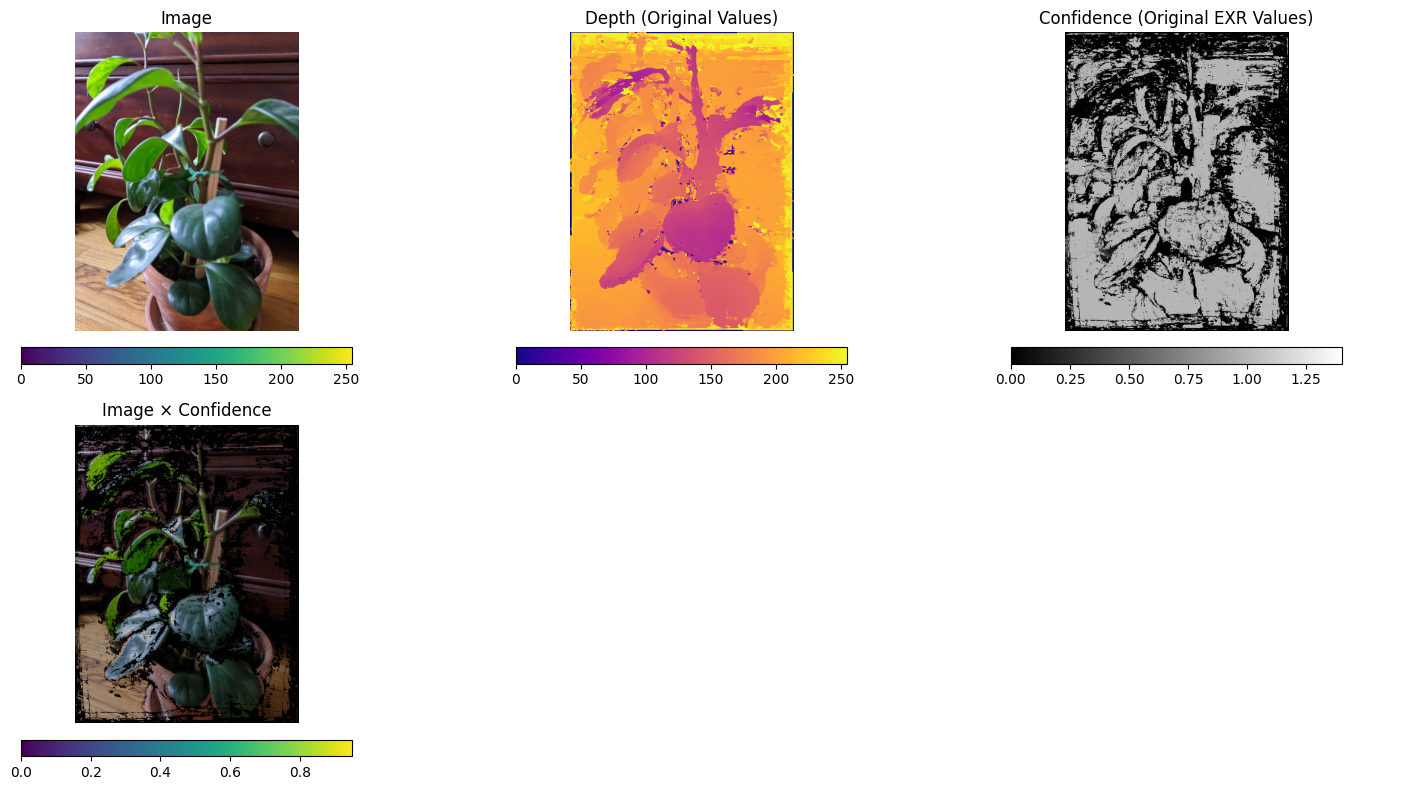

In [9]:
file_name = "/home1_0"
image_path = "/mnt/Velocity_Vault/Datasets/Autofocus/Test/scaled_images"+file_name+"/0.jpg"
depth_path = "/mnt/Velocity_Vault/Datasets/Autofocus/Test/merged_depth"+file_name+"/depth.png"
conf_path = "/mnt/Velocity_Vault/Datasets/Autofocus/Test/merged_conf"+file_name+"/conf.exr"

visualize_image_depth_conf(image_path, depth_path, conf_path)